<a href="https://colab.research.google.com/github/rinkamonic-tech/Rinka/blob/main/UTS_Data_Mining_Rinkamonic_Putri_Alfajri_147.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
import joblib

In [2]:
from google.colab import files
uploaded = files.upload()

Saving data_training.csv to data_training.csv
Saving data_testing.csv to data_testing.csv


In [3]:
PATH_TRAIN = 'data_training.csv'
PATH_TEST  = 'data_testing.csv'

df_train = pd.read_csv(PATH_TRAIN)
df_test  = pd.read_csv(PATH_TEST)

print(f'Training shape : {df_train.shape}')
print(f'Testing  shape : {df_test.shape}')

Training shape : (857, 13)
Testing  shape : (286, 12)


In [7]:
#Preview data training
print('=== Data Training (5 baris pertama) ===')
df_train.head()

=== Data Training (5 baris pertama) ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [8]:
#Priview data testing
print('=== Data Testing (5 baris pertama) ===')
df_test.head()

=== Data Testing (5 baris pertama) ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


In [6]:
print('=== Info Data Training ===')
df_train.info()

=== Info Data Training ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [9]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,857.0,8.261960,1.701992,4.60000,7.10000,7.90000,9.1000,15.6000
volatile acidity,857.0,0.529393,0.179162,0.12000,0.39500,0.52000,0.6400,1.5800
citric acid,857.0,0.267351,0.195144,0.00000,0.09000,0.25000,0.4200,1.0000
residual sugar,857.0,2.506184,1.293512,0.90000,1.90000,2.20000,2.6000,15.5000
chlorides,857.0,0.086830,0.048721,0.01200,0.07000,0.07900,0.0900,0.6110
free sulfur dioxide,857.0,15.782964,10.300402,1.00000,7.00000,14.00000,21.0000,68.0000
total sulfur dioxide,857.0,45.978413,31.692113,6.00000,21.00000,38.00000,63.0000,278.0000
density,857.0,0.996692,0.001901,0.99007,0.99552,0.99668,0.9978,1.0032
pH,857.0,3.313092,0.152079,2.74000,3.21000,3.31000,3.4000,4.0100
sulphates,857.0,0.656709,0.167364,0.39000,0.55000,0.62000,0.7300,2.0000


Preprocessing

In [11]:
print('=== Missing Values — Training ===')
mv_train = df_train.isnull().sum()
print(mv_train[mv_train > 0] if mv_train.any() else '✅ Tidak ada missing values pada data training!')

print('\n=== Missing Values — Testing ===')
mv_test = df_test.isnull().sum()
print(mv_test[mv_test > 0] if mv_test.any() else '✅ Tidak ada missing values pada data testing!')

=== Missing Values — Training ===
✅ Tidak ada missing values pada data training!

=== Missing Values — Testing ===
✅ Tidak ada missing values pada data testing!


In [13]:
# Jika ada missing values, lakukan imputasi dengan median (robust terhadap outlier)
from sklearn.impute import SimpleImputer

num_cols_train = df_train.select_dtypes(include=np.number).columns.tolist()
# Exclude target dari imputasi
target_col = 'quality'
if target_col in num_cols_train:
    num_cols_train.remove(target_col)

if df_train[num_cols_train].isnull().any().any():
    imputer = SimpleImputer(strategy='median')
    df_train[num_cols_train] = imputer.fit_transform(df_train[num_cols_train])
    df_test_num = [c for c in num_cols_train if c in df_test.columns]
    df_test[df_test_num] = imputer.transform(df_test[df_test_num])

In [14]:
dup_train = df_train.duplicated().sum()
print(f'Jumlah duplikat training : {dup_train}')
if dup_train > 0:
    df_train = df_train.drop_duplicates()
    print(f'  → Setelah dihapus: {df_train.shape}')

Jumlah duplikat training : 0


Distribusi Target (Quality)

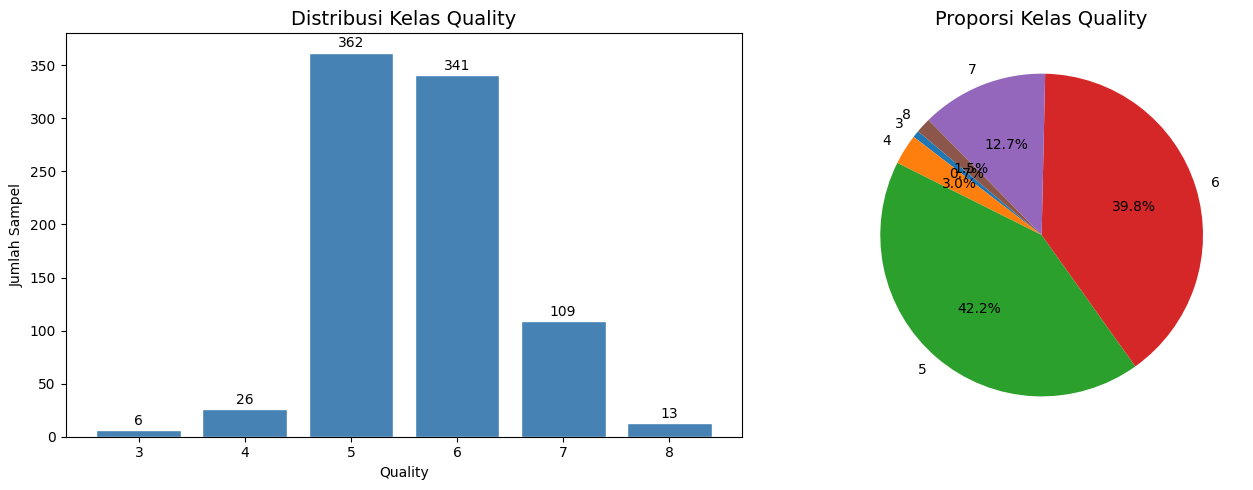


Ringkasan distribusi:
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
quality_counts = df_train[target_col].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Kelas Quality', fontsize=14)
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Jumlah Sampel')
for i, (q, v) in enumerate(quality_counts.items()):
    axes[0].text(q, v + 5, str(v), ha='center', fontsize=10)

# Pie chart
axes[1].pie(quality_counts.values, labels=quality_counts.index,
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Proporsi Kelas Quality', fontsize=14)

plt.tight_layout()
plt.savefig('distribusi_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nRingkasan distribusi:')
print(quality_counts)

Interpretasi: Terlihat bahwa kelas quality tidak seimbang (imbalaced). Kelas 5 dan Kelas 6 mendominasi dataset, sementara kelas ekstrem (3,4,8,9) memiliki jumlah sampel yang sangat sedikit. Hal ini perlu diperhatikan dalam pemilihan metrik evaluasi model.

Korelasi

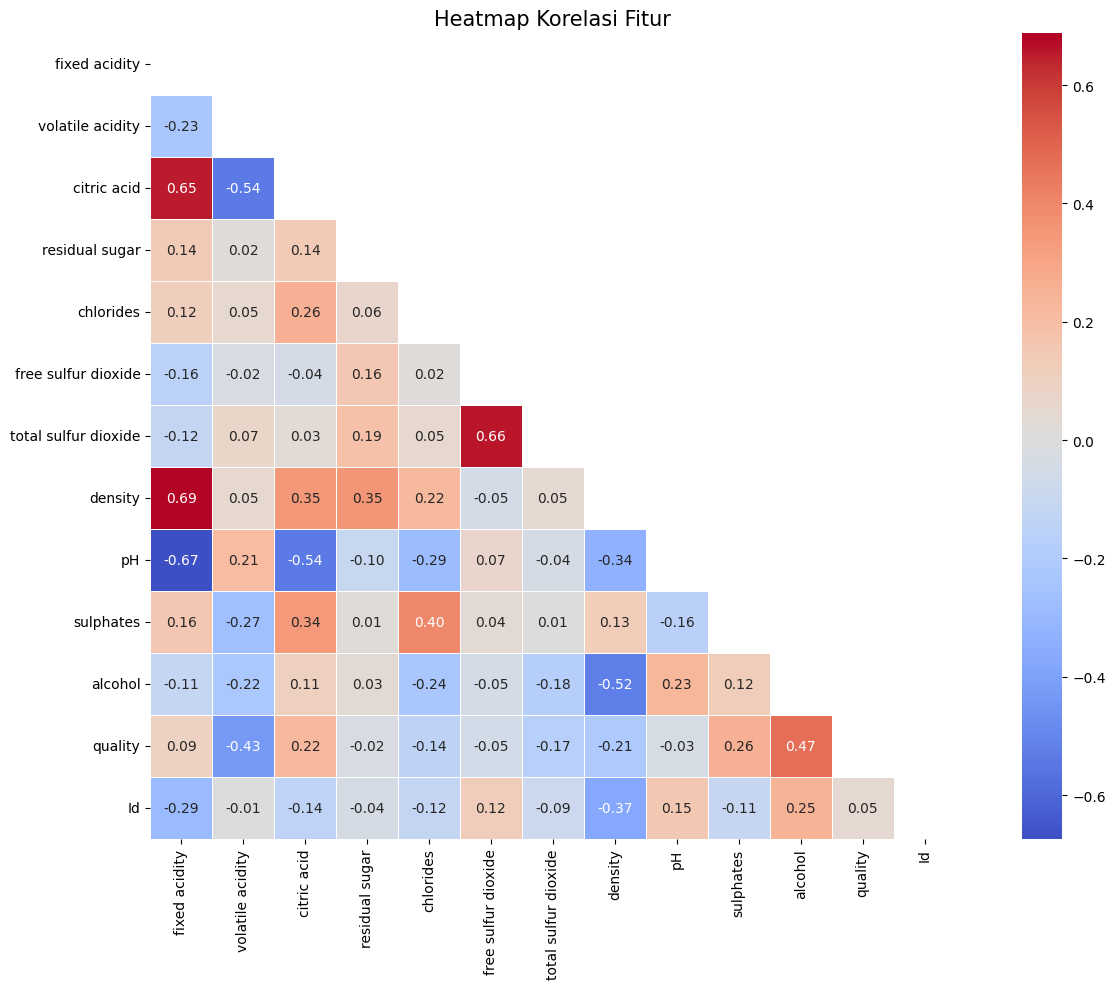

In [16]:
plt.figure(figsize=(14, 10))
corr = df_train.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur', fontsize=15)
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Fitur yang paling berkorelasi dengan quality
corr_with_quality = corr[target_col].drop(target_col).sort_values(key=abs, ascending=False)
print('=== Korelasi Fitur terhadap Quality ===')
print(corr_with_quality)

=== Korelasi Fitur terhadap Quality ===
alcohol                 0.473555
volatile acidity       -0.430059
sulphates               0.260703
citric acid             0.221263
density                -0.207903
total sulfur dioxide   -0.172737
chlorides              -0.144946
fixed acidity           0.092714
free sulfur dioxide    -0.054509
Id                      0.049030
pH                     -0.033199
residual sugar         -0.020511
Name: quality, dtype: float64


Persiapan Fitur dan Feature Scaling

In [18]:
# Identifikasi kolom ID di data testing
id_col = 'Id'  # sesuaikan jika nama kolom berbeda

# Pastikan kolom id ada
if id_col not in df_test.columns:
    # Coba cari kolom id dengan nama berbeda
    possible_ids = [c for c in df_test.columns if 'id' in c.lower()]
    if possible_ids:
        id_col = possible_ids[0]
    else:
        df_test.insert(0, 'Id', range(1, len(df_test)+1))
        id_col = 'Id'
    print(f'Kolom ID ditemukan: {id_col}')

test_ids = df_test[id_col]

# Kolom fitur (exclude target dari training, exclude id dari testing)
feature_cols = [c for c in df_train.columns if c not in [target_col, id_col]]
print(f'Fitur yang digunakan ({len(feature_cols)}): {feature_cols}')

X = df_train[feature_cols].copy()
y = df_train[target_col].copy()

X_submit = df_test[[c for c in feature_cols if c in df_test.columns]].copy()

print(f'\nShape X         : {X.shape}')
print(f'Shape y         : {y.shape}')
print(f'Shape X_submit  : {X_submit.shape}')

Fitur yang digunakan (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Shape X         : (857, 11)
Shape y         : (857,)
Shape X_submit  : (286, 11)


In [19]:
# Cek apakah ada kolom kategorikal (misal kolom 'type' red/white)
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f'Kolom kategorikal: {cat_cols}')

if cat_cols:
    for col in cat_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        X_submit[col] = le.transform(X_submit[col].astype(str))
    print('✅ Encoding kategorikal selesai.')
else:
    print('✅ Tidak ada kolom kategorikal.')

Kolom kategorikal: []
✅ Tidak ada kolom kategorikal.


In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'X_train: {X_train.shape}, X_val: {X_val.shape}')

X_train: (685, 11), X_val: (172, 11)


Pembuatan Model

1. Random Forest

In [21]:
# Pipeline: Scaling + Random Forest
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_val)

acc_rf = accuracy_score(y_val, y_pred_rf)
print(f'✅ Akurasi Random Forest (Validasi): {acc_rf:.4f} ({acc_rf*100:.2f}%)')

✅ Akurasi Random Forest (Validasi): 0.6105 (61.05%)


In [22]:
# Cross-validation 5-fold
cv_scores_rf = cross_val_score(rf_pipeline, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f'CV Scores RF    : {cv_scores_rf}')
print(f'CV Mean Accuracy: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')

CV Scores RF    : [0.65116279 0.65116279 0.65497076 0.64327485 0.53216374]
CV Mean Accuracy: 0.6265 ± 0.0473


2. Gradient Boosting

In [23]:
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)
y_pred_gb = gb_pipeline.predict(X_val)
acc_gb = accuracy_score(y_val, y_pred_gb)
print(f'✅ Akurasi Gradient Boosting (Validasi): {acc_gb:.4f} ({acc_gb*100:.2f}%)')

✅ Akurasi Gradient Boosting (Validasi): 0.5640 (56.40%)


3. Perbandingan Model

In [24]:
model_results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'Validation Accuracy': [acc_rf, acc_gb]
}).sort_values('Validation Accuracy', ascending=False)

print(model_results.to_string(index=False))

# Pilih model terbaik
best_model = rf_pipeline if acc_rf >= acc_gb else gb_pipeline
best_name  = 'Random Forest' if acc_rf >= acc_gb else 'Gradient Boosting'
y_pred_best = rf_pipeline.predict(X_val) if acc_rf >= acc_gb else gb_pipeline.predict(X_val)
print(f'\n🏆 Model terbaik: {best_name}')

            Model  Validation Accuracy
    Random Forest             0.610465
Gradient Boosting             0.563953

🏆 Model terbaik: Random Forest


Classification Report

In [25]:
print(f'=== Classification Report — {best_name} ===')
print(classification_report(y_val, y_pred_best, zero_division=0))

=== Classification Report — Random Forest ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.68      0.77      0.72        73
           6       0.57      0.63      0.60        68
           7       0.42      0.23      0.29        22
           8       1.00      0.33      0.50         3

    accuracy                           0.61       172
   macro avg       0.44      0.33      0.35       172
weighted avg       0.58      0.61      0.59       172



Interpretasi Classification Report:

*   Precision: dari semua prediksi kelas tertentu, berapa persen yang benar.
*   Recall: Dari semua data yang sebenarnya kelas tertentu, berapa persen yang berhasil diprediksi.
* F1-Score: Rata-rata harmonis presion dan recall. Penting untuk kelas yang tidak seimbang.
* Kelas 5 dan 6 mendapatkan nilai yang lebih baik karena lebih banyak sampel training.



Confusion Matrix

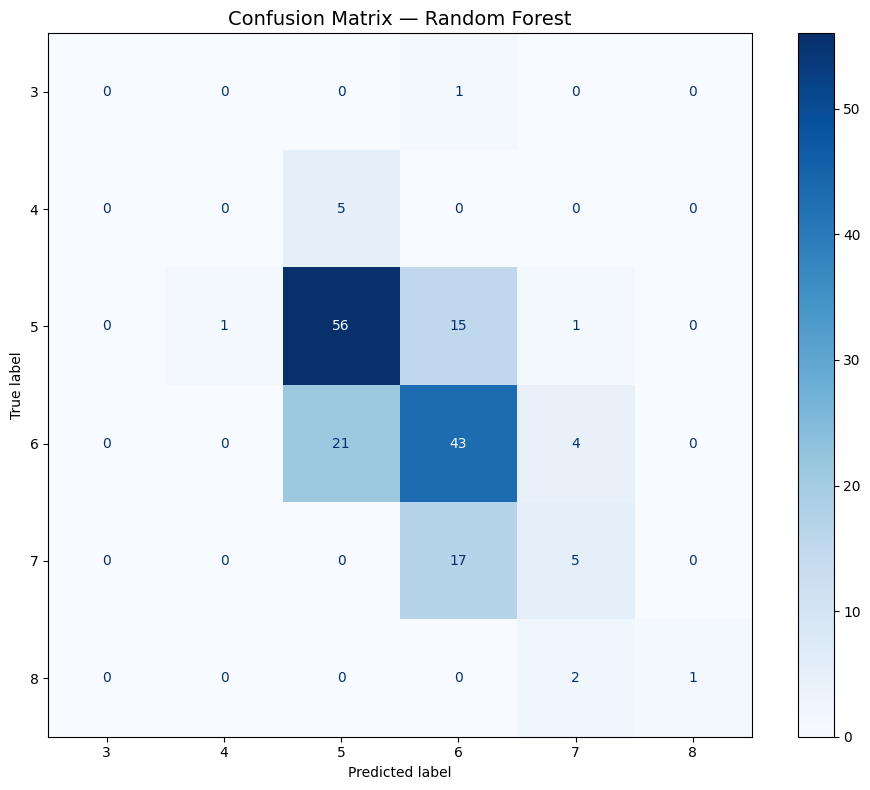

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_val, y_pred_best)
labels = sorted(y.unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Interpretasi Confusion Matrix:
* Diagonal utama menunjukkan prediksi yang benar (True Positive).
* Nilai di luar diagonal menunjukan kesalahan klasifikasi.
* Terlihat bahwa model paling akurat memprediksi kelas 5 dan 6, karena jumlah sampelnya terbanyak.

Feature Importance

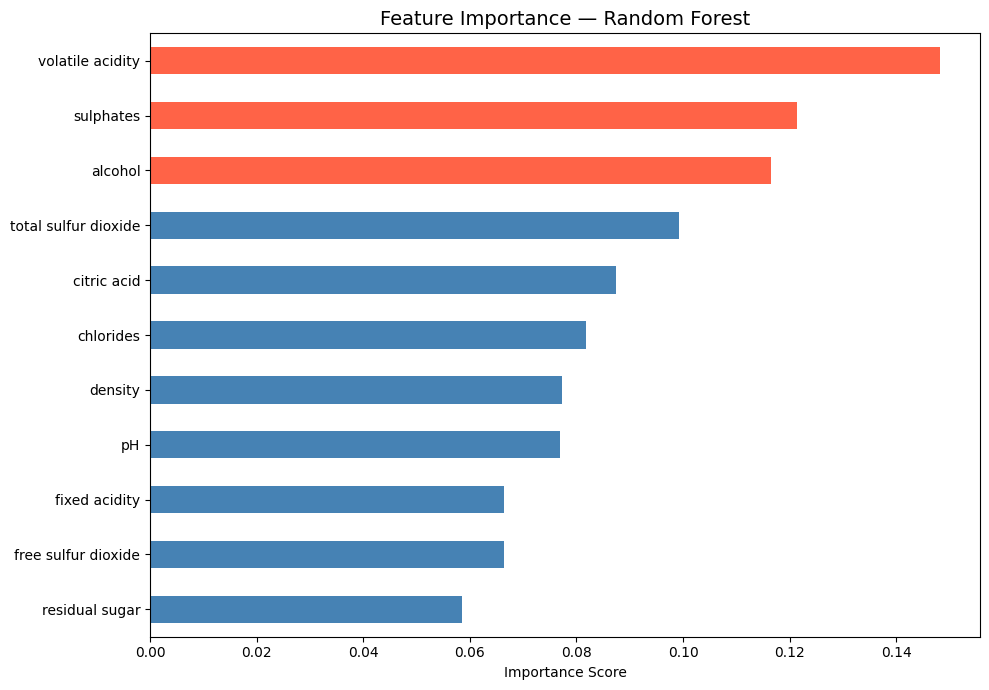


=== Top 5 Fitur Terpenting ===
volatile acidity        0.148315
sulphates               0.121464
alcohol                 0.116420
total sulfur dioxide    0.099220
citric acid             0.087398
dtype: float64


In [27]:
# Ambil feature importance dari model (hanya untuk RF dan GB)
clf = best_model.named_steps['clf']
importances = pd.Series(
    clf.feature_importances_, index=feature_cols
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['steelblue' if v < importances.quantile(0.75) else 'tomato' for v in importances]
importances.plot(kind='barh', color=colors)
plt.title(f'Feature Importance — {best_name}', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Top 5 Fitur Terpenting ===')
print(importances.sort_values(ascending=False).head())

Interpretasi Feature Importance:
Fitur dengan importance tertinggi paling banyak berkontribusi dalam pengambilan keputusan model. Pada dataset wine quality, biasanya alcohol, volatile acidity, dan sulphates menjadi fitur yang paling penting.



In [30]:
print('🔁 Melatih ulang model dengan seluruh data training...')
best_model.fit(X, y)

# Verifikasi akurasi pada data training (should be high)
y_train_pred = best_model.predict(X)
train_acc = accuracy_score(y, y_train_pred)
print(f'✅ Akurasi pada seluruh data training: {train_acc:.4f} ({train_acc*100:.2f}%)')

🔁 Melatih ulang model dengan seluruh data training...
✅ Akurasi pada seluruh data training: 1.0000 (100.00%)


In [31]:
# Prediksi data testing
y_pred_test = best_model.predict(X_submit)

print(f'✅ Prediksi selesai untuk {len(y_pred_test)} data.')
print(f'Distribusi hasil prediksi:')
pred_dist = pd.Series(y_pred_test).value_counts().sort_index()
print(pred_dist)

✅ Prediksi selesai untuk 286 data.
Distribusi hasil prediksi:
5    134
6    125
7     25
8      2
Name: count, dtype: int64


In [32]:
# Buat DataFrame hasil prediksi
df_hasil = pd.DataFrame({
    'Id': test_ids.values,
    'quality': y_pred_test
})

print('=== 10 Baris Pertama Hasil Prediksi ===')
print(df_hasil.head(10))

=== 10 Baris Pertama Hasil Prediksi ===
     Id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        6
5  1120        6
6   180        5
7    82        5
8   632        5
9   592        5


In [33]:
# ── UBAH 3 DIGIT TERAKHIR NIM ANDA DI SINI ──────────────────────────────────
NIM_3_TERAKHIR = '147'   # <-- Ganti dengan 3 digit terakhir NIM Anda
# ─────────────────────────────────────────────────────────────────────────────

output_filename = f'hasilprediksi_{NIM_3_TERAKHIR}.csv'
df_hasil.to_csv(output_filename, index=False)
print(f'✅ File hasil prediksi disimpan: {output_filename}')
print(f'   Jumlah baris: {len(df_hasil)}')
print(f'   Kolom: {df_hasil.columns.tolist()}')

✅ File hasil prediksi disimpan: hasilprediksi_147.csv
   Jumlah baris: 286
   Kolom: ['Id', 'quality']


In [34]:
from google.colab import files
files.download(output_filename)
print(f'📥 File {output_filename} sedang diunduh...')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 File hasilprediksi_147.csv sedang diunduh...


In [38]:
# Simpan model ke file .pkl
model_path = f'wine_quality_model_{NIM_3_TERAKHIR}.pkl'
joblib.dump(best_model, model_path)
print(f'✅ Model disimpan di: {model_path}')

# Verifikasi: load kembali model dan prediksi
loaded_model = joblib.load(model_path)
y_check = loaded_model.predict(X_submit[:3])
print(f'✅ Model berhasil di-load. Contoh prediksi 3 data pertama: {y_check}')

✅ Model disimpan di: wine_quality_model_147.pkl
✅ Model berhasil di-load. Contoh prediksi 3 data pertama: [5 6 5]


In [36]:
print('=' * 55)
print('       RINGKASAN HASIL UTS DATA MINING')
print('=' * 55)
print(f'Model yang digunakan      : {best_name}')
print(f'Jumlah fitur              : {len(feature_cols)}')
print(f'Jumlah data training      : {len(X)}')
print(f'Jumlah data testing       : {len(X_submit)}')
print(f'Akurasi validasi (20%)    : {max(acc_rf, acc_gb)*100:.2f}%')
print(f'CV Mean Accuracy (5-fold) : {cv_scores_rf.mean()*100:.2f}%')
print(f'File output               : {output_filename}')
print('=' * 55)

       RINGKASAN HASIL UTS DATA MINING
Model yang digunakan      : Random Forest
Jumlah fitur              : 11
Jumlah data training      : 857
Jumlah data testing       : 286
Akurasi validasi (20%)    : 61.05%
CV Mean Accuracy (5-fold) : 62.65%
File output               : hasilprediksi_147.csv


In [39]:
!pip install openpyxl

In [41]:
df=pd.read_csv('/content/hasilprediksi_147.csv')